In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns

In [ ]:
from vaccination_functions import *
from acs_data_functions import *

In [3]:
tx_mmr_vac_rates = pd.read_csv("../TX_MMR_vax_rate_24_25.csv")
counties_with_vac = tx_mmr_vac_rates['County'].unique()

In [4]:
age_df = pd.read_csv("../tx_county_agePop_24.csv")
age_var_df = pd.read_csv("../ageVars_acs.csv")

race_df = pd.read_csv("../tx_county_racePop_24.csv")
race_var_df = pd.read_csv("../raceVars_acs.csv")

education_df = pd.read_csv("../tx_county_education_24.csv")
education_var_df = pd.read_csv("../educationVars_acs.csv")

enrollment_df = pd.read_csv("../tx_county_enrollment_24.csv")
enrollment_var_df = pd.read_csv("../enrollmentVars_acs.csv")

poverty_df = pd.read_csv("../tx_county_poverty_24.csv")
poverty_var_df = pd.read_csv("../povertyVars_acs.csv")


In [5]:
age_with_var_all, age_with_var_no_gender = create_predictor_datasets(age_df, age_var_df, counties_with_vac)
race_with_var_all, race_with_var_no_gender = create_predictor_datasets(race_df, race_var_df, counties_with_vac)
education_with_var_all, education_with_var_no_gender = create_predictor_datasets(education_df, education_var_df, counties_with_vac)
enrollment_with_var_all, enrollment_with_var_no_gender = create_predictor_datasets(enrollment_df, enrollment_var_df, counties_with_vac)
poverty_with_var_all, poverty_with_var_no_gender = create_predictor_datasets(poverty_df, poverty_var_df, counties_with_vac)

In [6]:
age_with_var_no_gender['Estimate_Total_Under_5'] = age_with_var_all['Estimate_Total_Male_Under_5'] + age_with_var_all['Estimate_Total_Female_Under_5']
age_with_var_no_gender['Estimate_Total_5_9'] = age_with_var_all['Estimate_Total_Male_5_9'] + age_with_var_all['Estimate_Total_Female_5_9']
age_with_var_no_gender['Estimate_Total_10_14'] = age_with_var_all['Estimate_Total_Male_10_14'] + age_with_var_all['Estimate_Total_Female_10_14']
age_with_var_no_gender['Estimate_Total_15_17'] = age_with_var_all['Estimate_Total_Male_15_17'] + age_with_var_all['Estimate_Total_Female_15_17']
age_with_var_no_gender['Estimate_Total_18_19'] = age_with_var_all['Estimate_Total_Male_18_and_19'] + age_with_var_all['Estimate_Total_Female_18_and_19']
age_with_var_no_gender['Estimate_Total_21'] = age_with_var_all['Estimate_Total_Male_21'] + age_with_var_all['Estimate_Total_Female_21']
age_with_var_no_gender['Estimate_Total_22_24'] = age_with_var_all['Estimate_Total_Male_22_24'] + age_with_var_all['Estimate_Total_Female_22_24']
age_with_var_no_gender['Estimate_Total_25_29'] = age_with_var_all['Estimate_Total_Male_25_29'] + age_with_var_all['Estimate_Total_Female_25_29']
age_with_var_no_gender['Estimate_Total_30_34'] = age_with_var_all['Estimate_Total_Male_30_34'] + age_with_var_all['Estimate_Total_Female_30_34']
age_with_var_no_gender['Estimate_Total_35_39'] = age_with_var_all['Estimate_Total_Male_35_39'] + age_with_var_all['Estimate_Total_Female_35_39']


In [7]:
age_with_var_no_gender['Estimate_Total_40_44'] = age_with_var_all['Estimate_Total_Male_40_44'] + age_with_var_all['Estimate_Total_Female_40_44']
age_with_var_no_gender['Estimate_Total_45_49'] = age_with_var_all['Estimate_Total_Male_45_49'] + age_with_var_all['Estimate_Total_Female_45_49']
age_with_var_no_gender['Estimate_Total_50_54'] = age_with_var_all['Estimate_Total_Male_50_54'] + age_with_var_all['Estimate_Total_Female_50_54']
age_with_var_no_gender['Estimate_Total_55_59'] = age_with_var_all['Estimate_Total_Male_55_59'] + age_with_var_all['Estimate_Total_Female_55_59']
age_with_var_no_gender['Estimate_Total_60_61'] = age_with_var_all['Estimate_Total_Male_60_and_61'] + age_with_var_all['Estimate_Total_Female_60_and_61']
age_with_var_no_gender['Estimate_Total_62_64'] = age_with_var_all['Estimate_Total_Male_62_64'] + age_with_var_all['Estimate_Total_Female_62_64']
age_with_var_no_gender['Estimate_Total_65_66'] = age_with_var_all['Estimate_Total_Male_65_and_66'] + age_with_var_all['Estimate_Total_Female_65_and_66']
age_with_var_no_gender['Estimate_Total_67_69'] = age_with_var_all['Estimate_Total_Male_67_69'] + age_with_var_all['Estimate_Total_Female_67_69']
age_with_var_no_gender['Estimate_Total_70_74'] = age_with_var_all['Estimate_Total_Male_70_74'] + age_with_var_all['Estimate_Total_Female_70_74']
age_with_var_no_gender['Estimate_Total_75_79'] = age_with_var_all['Estimate_Total_Male_75_79'] + age_with_var_all['Estimate_Total_Female_75_79']
age_with_var_no_gender['Estimate_Total_80_84'] = age_with_var_all['Estimate_Total_Male_80_84'] + age_with_var_all['Estimate_Total_Female_80_84']
age_with_var_no_gender['Estimate_Total_85_over'] = age_with_var_all['Estimate_Total_Male_85_and_over'] + age_with_var_all['Estimate_Total_Female_85_and_over']

In [8]:
age_with_var_all_percent, age_with_var_no_gender_percent = create_predictor_percentages(age_with_var_all, age_with_var_no_gender)
race_with_var_all_percent, race_with_var_no_gender_percent = create_predictor_percentages(race_with_var_all, race_with_var_no_gender)
education_with_var_all_percent, education_with_var_no_gender_percent = create_predictor_percentages(education_with_var_all, education_with_var_no_gender)
enrollment_with_var_all_percent, enrollment_with_var_no_gender_percent = create_predictor_percentages(enrollment_with_var_all, enrollment_with_var_no_gender)

In [9]:
age_with_var_all_percent

variable,Estimate_Total,Percent_Female,Percent_Female_10_14,Percent_Female_15_17,Percent_Female_18_and_19,Percent_Female_20,Percent_Female_21,Percent_Female_22_24,Percent_Female_25_29,Percent_Female_30_34,...,Percent_Male_5_9,Percent_Male_60_and_61,Percent_Male_62_64,Percent_Male_65_and_66,Percent_Male_67_69,Percent_Male_70_74,Percent_Male_75_79,Percent_Male_80_84,Percent_Male_85_and_over,Percent_Male_Under_5
County,,,,,,,,,,,,,,,,,,,,,
Anderson,58439,22723,0.066585,0.038595,0.022928,0.007481,0.015359,0.028121,0.062140,0.055274,...,0.047934,0.022707,0.026403,0.017891,0.026935,0.027439,0.019795,0.016519,0.004704,0.042334
Andrews,18610,9506,0.088365,0.051231,0.018725,0.015148,0.008521,0.043867,0.055228,0.073322,...,0.070189,0.025154,0.038994,0.018014,0.011973,0.037346,0.010325,0.014609,0.002636,0.053713
Angelina,87275,44457,0.071057,0.044942,0.027105,0.010864,0.007783,0.039454,0.062217,0.063837,...,0.059297,0.027559,0.034145,0.016582,0.033584,0.043697,0.026251,0.022584,0.010767,0.068219
Aransas,24876,12657,0.062416,0.024492,0.002528,0.000474,0.004819,0.032156,0.070475,0.053962,...,0.043621,0.028317,0.053441,0.038301,0.051805,0.073328,0.055733,0.032981,0.027171,0.043375
Archer,8867,4374,0.063329,0.037723,0.020119,0.015318,0.002286,0.022405,0.045953,0.052812,...,0.068106,0.028711,0.049410,0.024483,0.040730,0.051191,0.041175,0.026486,0.016025,0.050300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wood,46961,23439,0.057426,0.035667,0.023124,0.009429,0.012885,0.025982,0.040019,0.050002,...,0.053949,0.041408,0.037454,0.030652,0.056373,0.071252,0.050846,0.030270,0.021894,0.043619
Yoakum,7571,3552,0.106700,0.057432,0.022523,0.055180,0.000000,0.009009,0.067849,0.065597,...,0.097039,0.011197,0.040309,0.025877,0.005972,0.030605,0.026624,0.017915,0.001742,0.137099
Young,18029,8626,0.072571,0.018201,0.029678,0.000927,0.004405,0.046140,0.051820,0.059240,...,0.061257,0.023929,0.033606,0.017973,0.052111,0.054025,0.033606,0.011911,0.024248,0.062321


In [10]:
age_corr_matrix = age_with_var_all_percent.drop(columns=["Estimate_Total", "Percent_Female", "Percent_Male"]).corr()
race_corr_matrix = race_with_var_all_percent.drop(columns="Estimate_Total").corr()
edu_corr_matrix = education_with_var_all_percent.drop(columns=["B15003_025", "Estimate_Total"]).corr()

<Axes: xlabel='variable', ylabel='variable'>

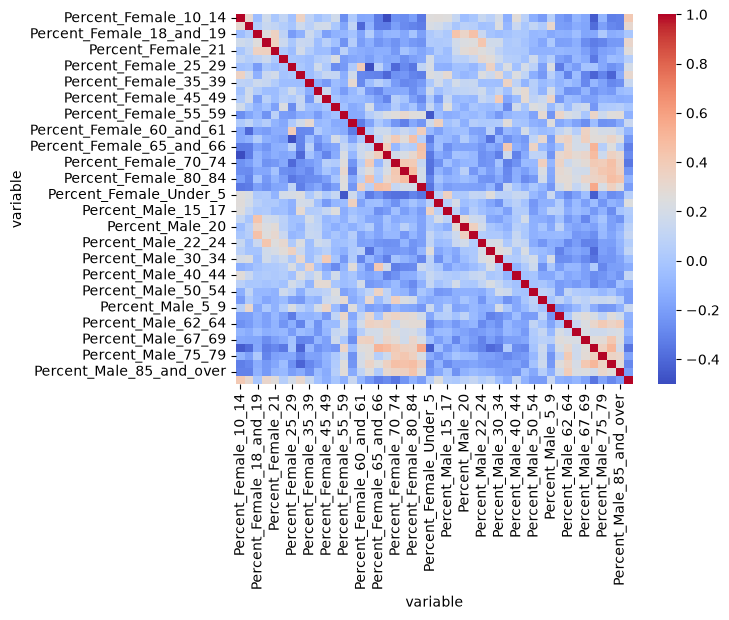

In [11]:
sns.heatmap(age_corr_matrix, cmap="coolwarm", fmt=".2f")

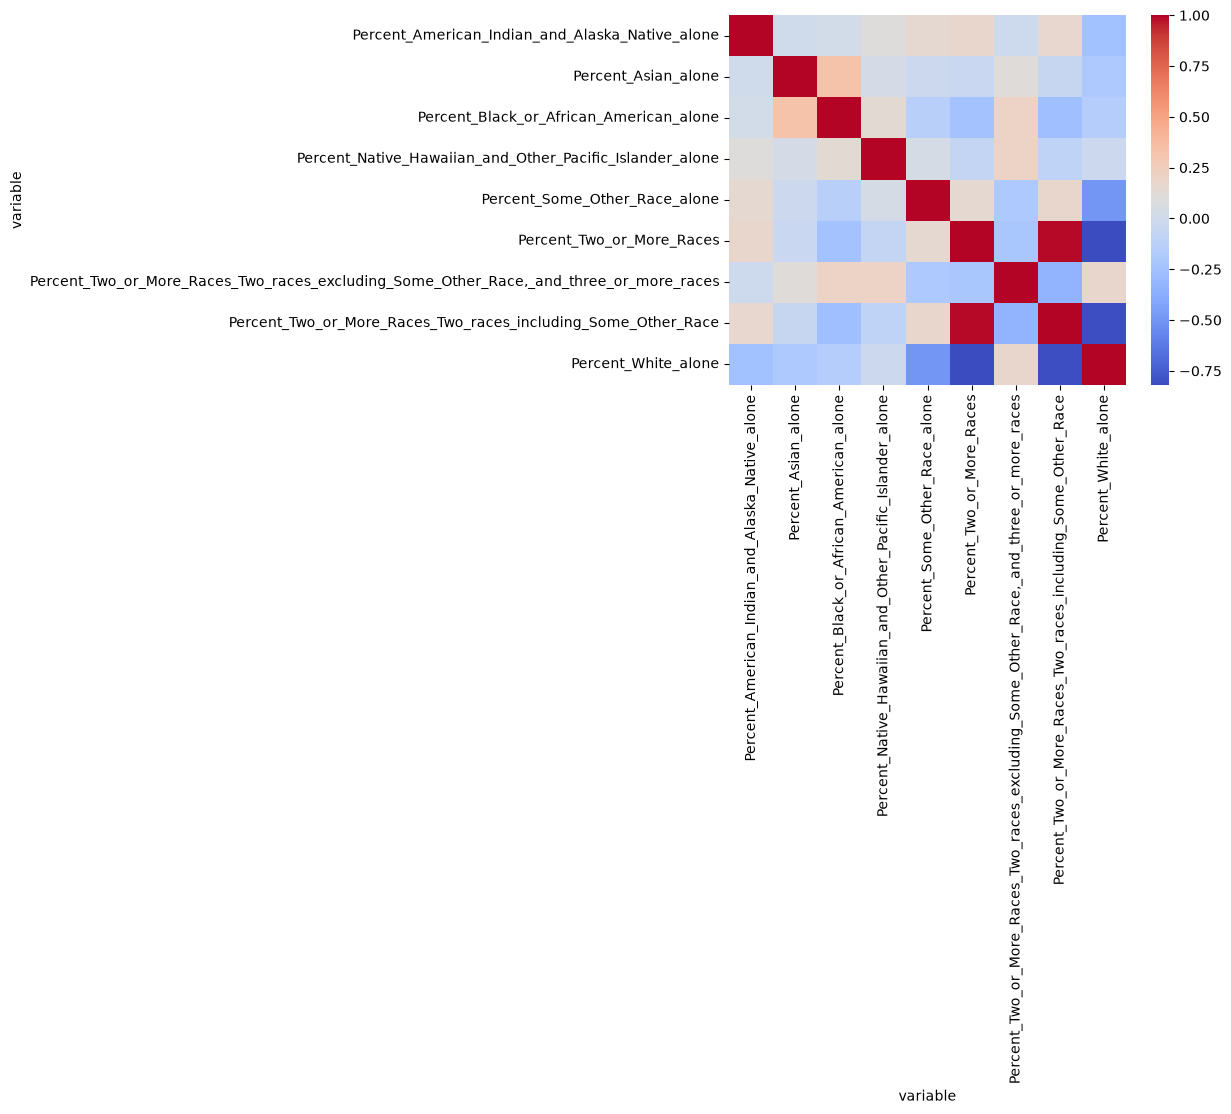

In [12]:
sns.heatmap(race_corr_matrix, cmap="coolwarm", fmt=".2f")
plt.savefig("../plots/race_predictors_correlation_matrix.png", bbox_inches="tight")

<Axes: xlabel='variable', ylabel='variable'>

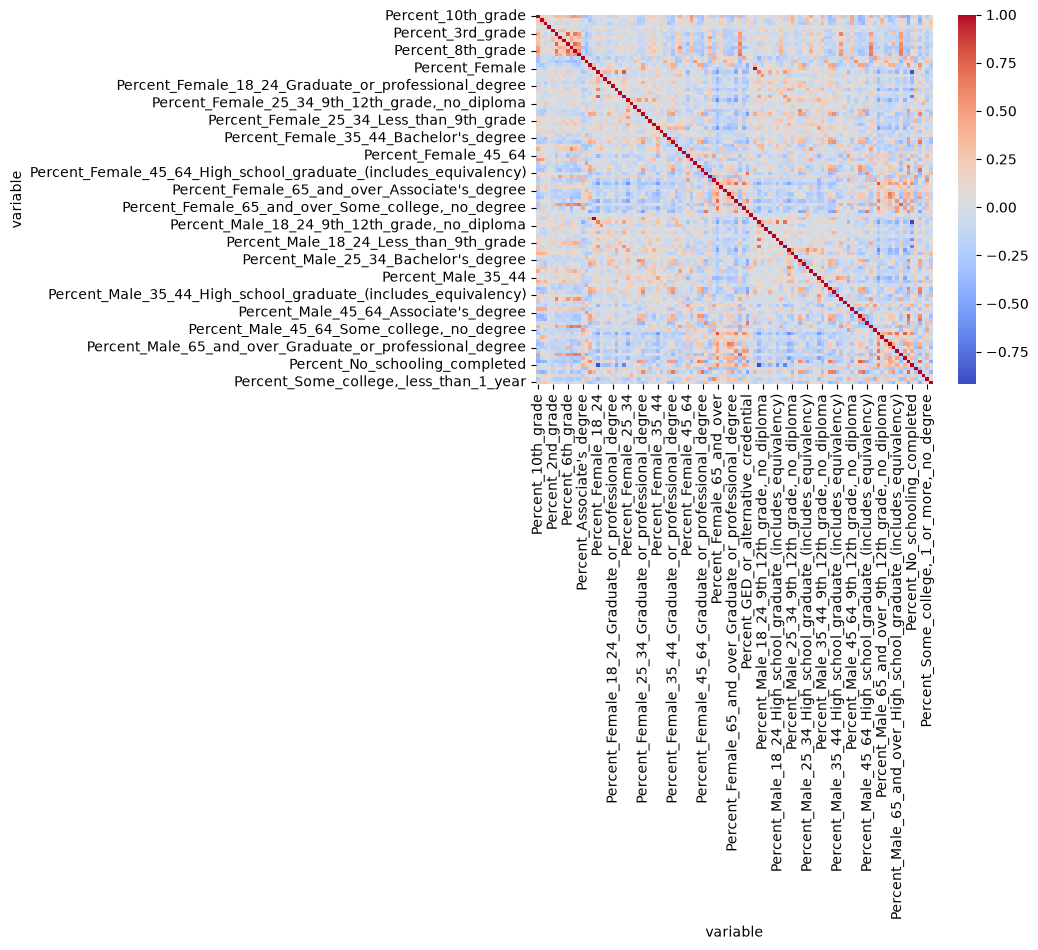

In [13]:
sns.heatmap(edu_corr_matrix, cmap="coolwarm", fmt=".2f")